In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def print_multiple(run_dirs, labels, title="comparison"):
    """
    run_dirs: пути к папкам
    labels: подписи (["SignMuon", "Adam", "SGD"])
    metric: что выдаем ("iters_to_converge", "final_loss", )
    """
    print(title)

    for run_dir, label in zip(run_dirs, labels):
        run_dir = Path(run_dir)

        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)

        iters_to_converge = data["iters_to_converge"]
        final_loss = data["final_loss"]


        print(label)
        print("iters_to_converge:", iters_to_converge)
        print(f"final_loss: {final_loss:.4f}")
        print('\n')

In [ ]:
# ============================================================
# Publication-ready plotting style (NeurIPS / ICML / AAAI)
# Run this cell once; all subsequent figures inherit the style.
# (inline — no separate style file)
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 1.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.9,
    "lines.linewidth": 3.5,
    "lines.markersize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.75",
    "legend.fancybox": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Colorblind-safe categorical palette (Okabe-Ito, medium pink & cyan), fixed order.
_PALETTE = ["#0072B2", "#D55E00", "#009E73", "#E55C94",
            "#E69F00", "#2BBAF4", "#F0E442", "#000000"]
_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]

_METRIC_NAMES = {
    "train_loss": "Train Loss",
    "loss_history": "Loss",
    "grad_norm_history": "Gradient Norm",
    "val_loss": "Validation Loss",
    "val_accuracy": "Validation Accuracy",
}


def plot_multiple_histories(run_dirs, labels, metric="train_loss", title="comparison",
                            target_loss=None, max_iterations=None, line_styles=None,
                            xlabel="Iterations", ylabel=None, figsize=(10, 6.5),
                            markevery=None, save_path=None):
    """
    Plot one synthetic metric across several runs.

    run_dirs        : paths to <run>/metrics.json (with data[metric])
    target_loss     : truncate loss curves at the first point <= target_loss
    max_iterations  : pad/truncate all curves to this length
    line_styles     : optional per-series dash pattern (drawn on top of color+marker)
    """
    if line_styles is None:
        line_styles = ["-"] * len(run_dirs)

    fig, ax = plt.subplots(figsize=figsize)

    all_histories = []
    for run_dir in run_dirs:
        run_dir = Path(run_dir)
        with open(run_dir / "metrics.json", "r") as f:
            data = json.load(f)
        all_histories.append(np.array(data[metric]))

    for i, (label, history, line_style) in enumerate(zip(labels, all_histories, line_styles)):
        values = history.copy()

        if target_loss is not None and metric in ["loss_history", "train_loss", "val_loss"]:
            mask = values <= target_loss
            if np.any(mask):
                first_idx = np.where(mask)[0][0]
                values = values[:first_idx + 1]

        if max_iterations is not None and len(values) < max_iterations:
            last_value = values[-1]
            pad_length = max_iterations - len(values)
            values = np.pad(values, (0, pad_length), "constant", constant_values=last_value)
        elif max_iterations is not None:
            values = values[:max_iterations]

        iterations = np.arange(0, len(values))

        me = markevery if markevery is not None else max(1, len(values) // 6)
        color = _PALETTE[i % len(_PALETTE)]
        marker = _MARKERS[i % len(_MARKERS)]

        ax.plot(
            iterations, values,
            label=label,
            color=color,
            linestyle=line_style,
            linewidth=3.5,
            marker=marker,
            markersize=11,
            markerfacecolor=color,
            markeredgecolor="white",
            markeredgewidth=1.5,
            markevery=me,
            solid_capstyle="round",
            zorder=3,
        )

    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel if ylabel else _METRIC_NAMES.get(metric, metric), fontsize=20)
    ax.tick_params(axis="both", labelsize=16, length=6, width=1.3)
    ax.grid(True, linestyle="--", linewidth=0.9, alpha=0.25, zorder=0)
    ax.legend(loc="best", fontsize=16, frameon=True, framealpha=0.95, edgecolor="0.75")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# target_loss = 0.01

In [4]:
print_multiple(
    run_dirs=[
        "saves_synthetic_01/SignMuon",
        "saves_synthetic_01/Muon",
        "saves_synthetic_01/SignSGD",
        "saves_synthetic_01/SGD",
        "saves_synthetic_01/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    title="",
)


SignMuon
iters_to_converge: 564
final_loss: 0.0099


Muon
iters_to_converge: 337
final_loss: 0.0098


SignSGD
iters_to_converge: 1525
final_loss: 0.0100


SGD
iters_to_converge: 254
final_loss: 0.0100


Adam
iters_to_converge: 97
final_loss: 0.0097




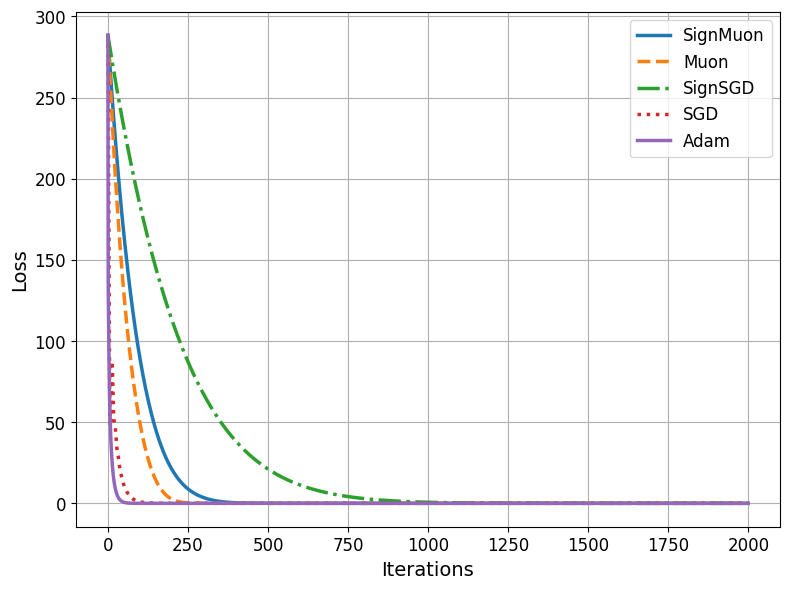

In [11]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic_01/SignMuon",
        "saves_synthetic_01/Muon",
        "saves_synthetic_01/SignSGD",
        "saves_synthetic_01/SGD",
        "saves_synthetic_01/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    metric="loss_history",
        title="",
    target_loss=0.01,
    max_iterations=2000,
    line_styles=["-", "--", "-.", ":", "-"]
)

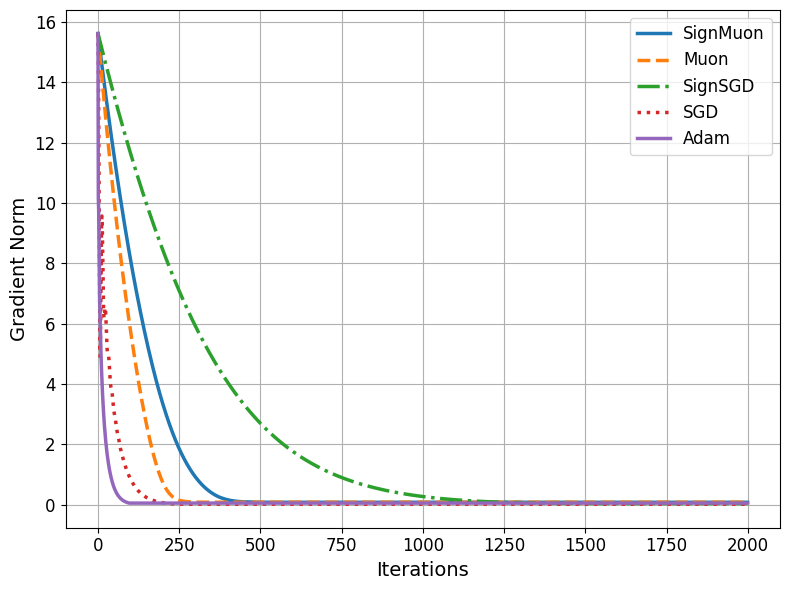

In [6]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic_01/SignMuon",
        "saves_synthetic_01/Muon",
        "saves_synthetic_01/SignSGD",
        "saves_synthetic_01/SGD",
        "saves_synthetic_01/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    metric="grad_norm_history",
    title="",
    target_loss=0.01,
    max_iterations=2000,
    line_styles=["-", "--", "-.", ":", "-"]
)

# target_loss = 0.001

In [7]:
print_multiple(
    run_dirs=[
        "saves_synthetic_001/SignMuon",
        "saves_synthetic_001/Muon",
        "saves_synthetic_001/SignSGD",
        "saves_synthetic_001/SGD",
        "saves_synthetic_001/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    title="",
)


SignMuon
iters_to_converge: 2104
final_loss: 0.0010


Muon
iters_to_converge: 1122
final_loss: 0.0010


SignSGD
iters_to_converge: 3120
final_loss: 0.0010


SGD
iters_to_converge: 972
final_loss: 0.0010


Adam
iters_to_converge: 202
final_loss: 0.0010




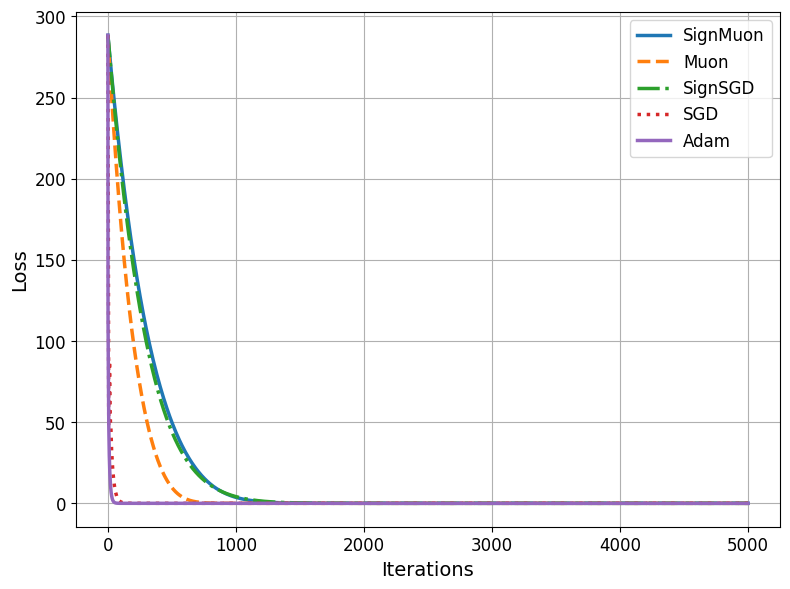

In [8]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic_001/SignMuon",
        "saves_synthetic_001/Muon",
        "saves_synthetic_001/SignSGD",
        "saves_synthetic_001/SGD",
        "saves_synthetic_001/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    metric="loss_history",
        title="",
    target_loss=0.001,
    max_iterations=5000,
    line_styles=["-", "--", "-.", ":", "-"]
)

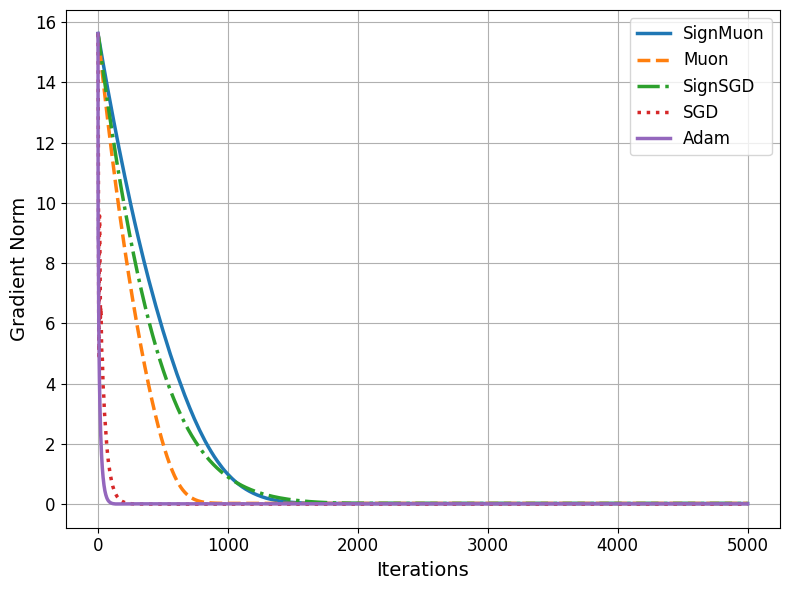

In [13]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic_001/SignMuon",
        "saves_synthetic_001/Muon",
        "saves_synthetic_001/SignSGD",
        "saves_synthetic_001/SGD",
        "saves_synthetic_001/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    metric="grad_norm_history",
    title="",
    target_loss=0.001,
    max_iterations=5000,
    line_styles=["-", "--", "-.", ":", "-"]
)

# target_loss = 0.0001

In [10]:
print_multiple(
    run_dirs=[
        "saves_synthetic_0001/SignMuon",
        "saves_synthetic_0001/Muon",
        "saves_synthetic_0001/SignSGD",
        "saves_synthetic_0001/SGD",
        "saves_synthetic_0001/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    title="",
)

FileNotFoundError: [Errno 2] No such file or directory: 'saves_synthetic_0001/SignMuon/metrics.json'

In [ ]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic_0001/SignMuon",
        "saves_synthetic_0001/Muon",
        "saves_synthetic_0001/SignSGD",
        "saves_synthetic_0001/SGD",
        "saves_synthetic_0001/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    metric="loss_history",
        title="",
    target_loss=0.0001,
    max_iterations=20000,
    line_styles=["-", "--", "-.", ":", "-"]
)

In [ ]:
plot_multiple_histories(
    run_dirs=[
        "saves_synthetic_0001/SignMuon",
        "saves_synthetic_0001/Muon",
        "saves_synthetic_0001/SignSGD",
        "saves_synthetic_0001/SGD",
        "saves_synthetic_0001/Adam",
    ],
    labels=[
        "SignMuon",
        "Muon",
        "SignSGD",
        "SGD",
        "Adam",
    ],
    metric="grad_norm_history",
    title="",
    target_loss=0.0001,
    max_iterations=20000,
    line_styles=["-", "--", "-.", ":", "-"]
)